# Loan Risk Classification
## Data Analytics project 25/26

**Models link** Models ['https://drive.google.com/file/d/1PaDsfRZqT69wO_gceiHac_6nEhWsoCh1/view?usp=sharing']

**Structure:**
- `config.py`: paths, seed, device
- `data_processing.py`: feature engineering, ML & DL preprocessors
- `models.py`: FFNN, TabNet, TabTransformer, training loop, evaluation
- `ml_pipeline.py`: LR, RF, KNN, SVM grid search wrappers

## 0. Setup & Imports

In [1]:
import sys
import os

sys.path.insert(0, os.path.join(os.getcwd(), "src"))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from config import SEED, DEVICE, MODEL_DIR, TRAIN_CSV, fix_random
from data_processing import (
    load_data,
    prepare_ml_data,
    prepare_dl_data,
    FFNNPreprocessor,
)
from ml_pipeline import (
    train_random_forest,
    train_knn,
    train_svm,
    train_lr,
    save_split_model,
    print_grid_results,
    plot_rf_feature_importances,
)
from models import (
    LoanDataset,
    TabularDataset,
    LoanClassifierFFNN,
    build_tabnet_classifier,
    train_tabnet,
    build_tab_transformer,
    train_model,
    evaluate_model,
    plot_losses,
    plot_confusion_matrix,
    plot_feature_importances,
    get_class_weights,
    get_class_weights_dict,
    create_loaders,
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score, 
    f1_score, 
    classification_report,
)

from sklearn.decomposition import PCA
from sklearn.preprocessing import (
    RobustScaler, 
    StandardScaler, 
    MinMaxScaler
)

fix_random(SEED)
print(f"Device: {DEVICE}")

Device: mps


## 1. Data Loading & Visualization

In [ ]:
df = load_data(TRAIN_CSV)
df.head()

In [ ]:
df.info()

In [ ]:
# Target distribution
class_counts = df["grade"].value_counts().sort_index()
plt.figure(figsize=(10, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Distribution of Target Classes (Grade)", fontsize=14, fontweight="bold")
plt.xlabel("Grade")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
# PCA visualization
X_numeric = df.select_dtypes(include=[np.number]).fillna(0)
X_pca = PCA(n_components=2).fit_transform(X_numeric)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df["grade"], palette="viridis", alpha=0.3, s=10)
plt.title("PCA of Numeric Features (2D)")
plt.tight_layout()
plt.show()

In [ ]:
X_raw, y_raw, fe_instance, prep_instance, le = prepare_ml_data(TRAIN_CSV)
print("X_raw shape:", X_raw.shape)
X_raw.head()

In [ ]:
import pandas as pd
import numpy as np

def print_skewness_report(X):
    # 1. Identify Numerical Columns
    num_cols = X.select_dtypes(include=[np.number]).columns
    
    # 2. Calculate Skewness
    skews = X[num_cols].skew()
    
    # 3. Categorize
    skewed_log_candidates = []   # |skew| > 1 AND No Negatives
    skewed_power_candidates = [] # |skew| > 1 AND Has Negatives
    non_skewed = []              # |skew| <= 1
    
    for col in num_cols:
        skew_val = skews[col]
        has_negatives = (X[col] < 0).any()
        
        if abs(skew_val) > 1:
            if has_negatives:
                skewed_power_candidates.append(col)
            else:
                skewed_log_candidates.append(col)
        else:
            non_skewed.append(col)

    # 4. Print Report
    print("====== Numerical Feature Skewness Report ======")
    print(f"Total Numerical Features: {len(num_cols)}")
    print("-" * 45)
    print(f"Non-Skewed (|skew| <= 1):         {len(non_skewed)}")
    print(f"Skewed (|skew| > 1):              {len(skewed_log_candidates) + len(skewed_power_candidates)}")
    print(f"  ├─ Positive Only (Log1p):       {len(skewed_log_candidates)}")
    print(f"  └─ With Negatives (Yeo-Johnson):{len(skewed_power_candidates)}")
    print("-" * 45)
    
    # Optional: Print the actual column names
    print(f"\n[Log1p Candidates]: {skewed_log_candidates}")
    print(f"\n[Yeo-Johnson Candidates]: {skewed_power_candidates}")
    print(f"\n[Non-Skewed (Direct to Scaler)]: {non_skewed}")

# Usage
print_skewness_report(X_raw)

In [ ]:
def visualize_data_quality(X, y):
    """
    Generates 2 key plots for Loan Risk Analysis.
    """
    # Combine for easier plotting
    df_plot = X.copy()
    #df_plot['grade'] = y
    
    plt.figure(figsize=(12, 6))
    # Plot missing values as binary (White=Missing, Black=Present)
    sns.heatmap(df_plot.isnull(), cbar=False, yticklabels=False, cmap='viridis')
    plt.title("Missing Value Patterns (Yellow = Missing)")
    plt.show()

    # correlation heatmap (to check multicollinearity)
    num_df = df_plot.select_dtypes(include=[np.number])
    corr = num_df.corr()
    
    plt.figure(figsize=(10, 8))
    # Mask the upper triangle (redundant)
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, cmap='coolwarm', vmax=1, vmin=-1, center=0,
                square=True, linewidths=.5, cbar_kws={"shrink": .5})
    plt.title("Correlation Heatmap (Check for Multicollinearity)")
    plt.show()

visualize_data_quality(X_raw, y_raw)

In [ ]:
def visualize_specific_issues(X):
    """
    Plots specific diagrams for high missingness and high collinearity.
    """
    # ------------------------------------------------------
    # 1. PLOT FEATURES WITH > 80% MISSING VALUES
    # ------------------------------------------------------
    # Calculate missing percentage for every column
    missing_pct = X.isnull().mean() * 100
    
    # Filter: Keep only those > 80%
    high_missing = missing_pct[missing_pct > 80].sort_values(ascending=False)
    
    plt.figure(figsize=(10, len(high_missing) * 0.4 if len(high_missing) > 0 else 6))
    
    if len(high_missing) > 0:
        sns.barplot(x=high_missing.values, y=high_missing.index, palette="Reds_r")
        plt.title(f"Features with > 80% Missing Values ({len(high_missing)} features)")
        plt.xlabel("Percent Missing (%)")
        plt.axvline(x=80, color='black', linestyle='--', label='80% Threshold')
        plt.legend()
    else:
        plt.text(0.5, 0.5, "No features found with > 80% missing values", 
                 ha='center', va='center', fontsize=14)
        plt.title("Missing Value Check")
        
    plt.tight_layout()
    plt.show()

    # Select numeric columns only
    num_df = X.select_dtypes(include=[np.number])
    corr_matrix = num_df.corr().abs()

    # Create a mask to ignore the diagonal (self-correlation is always 1)
    # and the lower triangle (since matrix is symmetric)
    upper_tri_mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    upper_tri = corr_matrix.where(upper_tri_mask)

    # Find columns that have ANY correlation > 0.95 with another column
    # We check columns (axis 1) that have any value > 0.95
    to_drop_candidates = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]
    
    # Also get the rows involved to make a square matrix of "problem features"
    # (i.e. if A correlates with B, we want to see both A and B in the plot)
    high_corr_pairs = set()
    for col in upper_tri.columns:
        # Get rows where value > 0.95
        rows = upper_tri.index[upper_tri[col] > 0.95].tolist()
        if rows:
            high_corr_pairs.add(col)
            high_corr_pairs.update(rows)
            
    problem_features = list(high_corr_pairs)

    plt.figure(figsize=(12, 10))
    
    if len(problem_features) > 1:
        # Slice the original matrix to keep ONLY these features
        subset_corr = corr_matrix.loc[problem_features, problem_features]
        
        # Plot heatmap
        mask = np.triu(np.ones_like(subset_corr, dtype=bool))
        sns.heatmap(subset_corr, mask=mask, cmap='coolwarm', 
                    vmin=-1, vmax=1, center=0, annot=False, linewidths=0.5)
        plt.title(f"High Collinearity Cluster (> 0.95) - {len(problem_features)} Features")
    else:
        plt.text(0.5, 0.5, "No feature pairs found with correlation > 0.95", 
                 ha='center', va='center', fontsize=14)
        plt.title("Collinearity Check")
        
    plt.tight_layout()
    plt.show()

# --- RUN THE FUNCTION ---
visualize_specific_issues(X_raw)

# 2. ML Models

The ML pipelines use all the data with `GridSearchCV` (3-fold stratified CV).

## 2.1 Logistic Regression

In [ ]:
# lr_param_grid = {
#     "preprocessor__scaler": [StandardScaler(), RobustScaler()], 
#     "classifier__C": [0.1, 1, 10], 
#     "classifier__solver": ["lbfgs"],
#     "classifier__penalty": ["l2", "l1"],
#     "classifier__max_iter": [1000]
# }

lr_param_grid = {
    "preprocessor__scaler": [RobustScaler()], 
    "classifier__C": [10], 
    "classifier__solver": ["lbfgs"],
    "classifier__penalty": ["l2"],
    "classifier__max_iter": [1000]
}

gs_lr = train_lr(
    X=X_raw, 
    y=y_raw, 
    feature_engineer=fe_instance, 
    preprocessor=prep_instance, 
    param_grid=lr_param_grid,
    cv=3
)

In [ ]:
# try:
#     save_split_model(gs_lr, "lr")
# except Exception as e:
#     print(f"Error saving model: {e}")

print_grid_results(gs_lr, "Logistic Regression")

## 2.1 Random Forest

In [ ]:
rf_param_grid = {
    "classifier__n_estimators": [300],
    "classifier__max_depth": [1000],
    "classifier__min_samples_split": [8],
    "classifier__min_samples_leaf": [1],
    "classifier__max_features": [0.3],
}

gs_rf = train_random_forest(
    X=X_raw, 
    y=y_raw, 
    feature_engineer=fe_instance, 
    preprocessor=prep_instance, 
    param_grid=rf_param_grid,
    cv=3
)

In [ ]:
try:
    save_split_model(gs_rf, "rf")
except Exception as e:
    print(f"Error saving model: {e}")

print_grid_results(gs_rf, "Random Forest")

In [ ]:
plot_rf_feature_importances(gs_rf, top_k=20, save_path=os.path.join(MODEL_DIR + "/images", "rf_fi.png"))

### 2.2 KNN

In [ ]:
knn_param_grid = {
    "pca__n_components": [30],
    "preprocessor__scaler": [StandardScaler()],
    "classifier__n_neighbors": [30],
    "classifier__weights": ["distance"],
    "classifier__p": [2],
}

gs_knn = train_knn(
    X=X_raw, 
    y=y_raw, 
    feature_engineer=fe_instance, 
    preprocessor=prep_instance, 
    param_grid=knn_param_grid,
    cv=3
)

In [ ]:
try:
    save_split_model(gs_knn, "knn")
except Exception as e:
    print(f"Error saving model: {e}")

print_grid_results(gs_knn, "KNN")

### 2.3 SVM

In [ ]:
svm_param_grid = {
    "preprocessor__scaler": [StandardScaler()],
    "classifier__C": [100],
    "classifier__kernel": ["rbf"],
    "classifier__gamma": ["scale"],
    "classifier__max_iter": [1000],
}

gs_svm = train_svm(
    X=X_raw, 
    y=y_raw, 
    feature_engineer=fe_instance, 
    preprocessor=prep_instance, 
    param_grid=svm_param_grid,
    cv=3
)

In [ ]:
try:
    save_split_model(gs_svm, "svm")
except Exception as e:
    print(f"Error saving model: {e}")
    
print_grid_results(gs_svm, "SVM")

# 3. Deep Learning Models

DL uses an explicit train/val/test split. Preprocessing is fit on train only.

In [2]:
# Prepare DL data
dl_data_raw = prepare_dl_data(TRAIN_CSV, val_size=0.10, test_size=0.10)

Loaded 148301 rows  (dropped 0 duplicates)
Train: 118639 (80.0%)
Val  : 14831 (10.0%)
Test : 14831 (10.0%)


In [3]:
print(f"\nDL data shapes:")
print(f"  X_train: {dl_data_raw['X_train'].shape}")
print(f"  X_val  : {dl_data_raw['X_val'].shape}")
print(f"  X_test : {dl_data_raw['X_test'].shape}")
print(f"  Num cols: {dl_data_raw['num_num_cols']}, Cat cols: {dl_data_raw['num_cat_cols']}")
print(f"  Classes : {dl_data_raw['num_classes']}")
print(f"  Feature names ({len(dl_data_raw['feature_names'])}): {dl_data_raw['feature_names'][:10]}...")


DL data shapes:
  X_train: (118639, 144)
  X_val  : (14831, 144)
  X_test : (14831, 144)
  Num cols: 112, Cat cols: 32
  Classes : 7
  Feature names (144): ['loan_contract_approved_amount', 'loan_portfolio_total_funded', 'investor_side_funded_amount', 'loan_contract_interest_rate', 'loan_payment_installments_count', 'borrower_income_annual', 'borrower_dti_ratio', 'credit_delinquencies_2yrs', 'fico_score_low_bound', 'fico_score_high_bound']...


In [4]:
# Instantiate the class
dl_pipeline = FFNNPreprocessor()

print("Fitting DL Preprocessor...")
dl_pipeline.fit(dl_data_raw['X_train'])

# Save preprocessor for ffnn, tabNet and tabTransformer
with open("models/ff_preprocessor.pkl", "wb") as f:
    pickle.dump(dl_pipeline, f)
print("Saved models/ffnn_preprocessor.pkl")

Fitting DL Preprocessor...
Saved models/ffnn_preprocessor.pkl


In [5]:
X_train_np = dl_pipeline.transform(dl_data_raw['X_train'])
X_val_np   = dl_pipeline.transform(dl_data_raw['X_val'])
X_test_np  = dl_pipeline.transform(dl_data_raw['X_test'])

print(f"\nDL data shapes:")
print(f"  X_train: {X_train_np.shape}")
print(f"  X_val  : {X_val_np.shape}")
print(f"  X_test : {X_test_np.shape}")

meta = dl_pipeline.get_metadata()
print(f"Metadata Extracted: {meta['num_num_cols']} numeric, {meta['num_cat_cols']} categorical")


DL data shapes:
  X_train: (118639, 126)
  X_val  : (14831, 126)
  X_test : (14831, 126)
Metadata Extracted: 113 numeric, 13 categorical


In [6]:
# Class weights (shared across all DL models)
class_weights_array = get_class_weights(dl_data_raw["y_train"])
class_weights_dict = get_class_weights_dict(dl_data_raw["y_train"])
class_names = [f"Grade {c}" for c in dl_data_raw["label_encoder"].classes_]
feature_names = dl_data_raw["feature_names"]

print(f"Class weights: {dict(enumerate(class_weights_array))}")
print(f"Class names: {class_names}")
print(f"Feature names: {len(feature_names)} total")

for name, y in [("Train", dl_data_raw["y_train"]),
                ("Val",   dl_data_raw["y_val"]),
                ("Test",  dl_data_raw["y_test"])]:
    unique, counts = np.unique(y, return_counts=True)
    pcts = counts / counts.sum() * 100
    print(f"{name:5s}: {dict(zip(unique, [f'{p:.1f}%' for p in pcts]))}")

Class weights: {0: np.float32(0.7984373), 1: np.float32(0.5614107), 2: np.float32(0.57132745), 3: np.float32(0.9966732), 4: np.float32(1.7532252), 5: np.float32(2.8158214), 6: np.float32(3.4823153)}
Class names: ['Grade A', 'Grade B', 'Grade C', 'Grade D', 'Grade E', 'Grade F', 'Grade G']
Feature names: 144 total
Train: {np.int64(0): '17.9%', np.int64(1): '25.4%', np.int64(2): '25.0%', np.int64(3): '14.3%', np.int64(4): '8.1%', np.int64(5): '5.1%', np.int64(6): '4.1%'}
Val  : {np.int64(0): '17.9%', np.int64(1): '25.4%', np.int64(2): '25.0%', np.int64(3): '14.3%', np.int64(4): '8.1%', np.int64(5): '5.1%', np.int64(6): '4.1%'}
Test : {np.int64(0): '17.9%', np.int64(1): '25.4%', np.int64(2): '25.0%', np.int64(3): '14.3%', np.int64(4): '8.1%', np.int64(5): '5.1%', np.int64(6): '4.1%'}


### 3.1 TabNet

In [ ]:
# ── TabNet Hyperparameters (edit here) ──
TABNET_HP = dict(
    # Architecture
    n_d=64,
    n_a=64,
    n_steps=3,
    gamma=1.3,
    n_independent=2,
    n_shared=2,
    cat_emb_dim=10,
    # Optimization
    lr=0.02,
    scheduler_step_size=20,
    scheduler_gamma=0.7,
    # Regularization
    lambda_sparse=1e-5,
    momentum=0.02,
    mask_type="entmax",
    # Training
    max_epochs=200,
    patience=20,
    batch_size=1024,
    virtual_batch_size=128,
)

In [ ]:
# Build TabNet
tabnet_model = build_tabnet_classifier(
    cat_indices=meta["cat_indices"],
    cat_cardinalities=meta["cat_cardinalities"],
    device=DEVICE,
    seed=SEED,
    n_d=TABNET_HP["n_d"],
    n_a=TABNET_HP["n_a"],
    n_steps=TABNET_HP["n_steps"],
    gamma=TABNET_HP["gamma"],
    n_independent=TABNET_HP["n_independent"],
    n_shared=TABNET_HP["n_shared"],
    cat_emb_dim=TABNET_HP["cat_emb_dim"],
    lr=TABNET_HP["lr"],
    scheduler_step_size=TABNET_HP["scheduler_step_size"],
    scheduler_gamma=TABNET_HP["scheduler_gamma"],
    lambda_sparse=TABNET_HP["lambda_sparse"],
    momentum=TABNET_HP["momentum"],
    mask_type=TABNET_HP["mask_type"],
)

In [ ]:
# Train TabNet
tabnet_model = train_tabnet(
    model=tabnet_model,
    X_train=X_train_np,
    y_train=dl_data_raw["y_train"],
    X_val=X_val_np,
    y_val=dl_data_raw["y_val"],
    max_epochs=TABNET_HP["max_epochs"],
    patience=TABNET_HP["patience"],
    batch_size=TABNET_HP["batch_size"],
    virtual_batch_size=TABNET_HP["virtual_batch_size"],
    class_weights=class_weights_dict,
)

In [ ]:
# Plot TabNet training history
tabnet_train_loss = tabnet_model.history["loss"]
tabnet_val_loss = tabnet_model.history["val_0_logloss"]
plot_losses(tabnet_train_loss, tabnet_val_loss, title="TabNet: Training vs Validation Loss")

In [ ]:

y_pred_tabnet = tabnet_model.predict(X_test_np)
y_test = dl_data_raw["y_test"]

print(f"\n{'='*50}")
print(f"  TabNet Test Set Evaluation")
print(f"{'='*50}")
print(f"  Accuracy          : {accuracy_score(y_test, y_pred_tabnet):.4f}")
print(f"  Balanced Accuracy : {balanced_accuracy_score(y_test, y_pred_tabnet):.4f}")
print(f"  F1 (weighted)     : {f1_score(y_test, y_pred_tabnet, average='weighted'):.4f}")
print(f"  F1 (macro)        : {f1_score(y_test, y_pred_tabnet, average='macro'):.4f}")
print()
print(classification_report(y_test, y_pred_tabnet, target_names=class_names))

plot_confusion_matrix(y_test, y_pred_tabnet, class_names=class_names, title="TabNet Confusion Matrix")

In [ ]:
# 1. Extract the feature names from the internal ColumnTransformer
# The ColumnTransformer stores the columns used for each step in .transformers_
# structure: [(name, transformer, columns), ...]

ct = dl_pipeline.dl_preprocessor_

# Index 0 is the "num" pipeline (Numerical)
# Index 1 is the "cat" pipeline (Categorical)
num_cols = ct.transformers_[0][2]
cat_cols = ct.transformers_[1][2]

# The output array is always [Numerical features | Categorical features]
correct_feature_names = num_cols + cat_cols

print(f"Correct feature count: {len(correct_feature_names)}") 
# 2. Now plot with the correct names
plot_feature_importances(
    importances=tabnet_model.feature_importances_,
    feature_names=correct_feature_names,
    top_k=20,
    title="TabNet — Feature Importances",
)

In [ ]:
#tabnet_save_path = os.path.join(MODEL_DIR, "best_tabnet")
#tabnet_model.save_model(tabnet_save_path)
#print(f"TabNet model saved to {tabnet_save_path}")

with open("models/tb.pkl", "wb") as f:
    pickle.dump(tabnet_model, f)

### 3.2 Feed-Forward Neural Network (FFNN)

In [12]:
FFNN_HP = dict(
    # Architecture
    hidden_units=[128, 64, 32],
    dropout_rates=[0.5, 0.2],
    # Training
    num_epochs=300,
    batch_size=256,
    learning_rate=3e-4,
    weight_decay=1e-3,
    patience=15,
    scheduler_patience=5,
    scheduler_factor=0.3,
)

In [13]:
# train_ds = LoanDataset(X_train_np, dl_data_raw["y_train"])
# val_ds   = LoanDataset(X_val_np,   dl_data_raw["y_val"])
# test_ds  = LoanDataset(X_test_np,  dl_data_raw["y_test"])

# train_loader, val_loader, test_loader = create_loaders(
#     train_ds, val_ds, test_ds, batch_size=FFNN_HP["batch_size"]
# )

# print(f"Input dim: {train_ds.num_features}, Output dim: {train_ds.num_classes}")

meta = dl_pipeline.get_metadata() # dl_preprocessor is your fitted FFNNPreprocessor
n_num = meta["num_num_cols"]

# 2. Instantiate Datasets
train_ds = LoanDataset(X_train_np, dl_data_raw["y_train"], num_num_cols=n_num)
val_ds   = LoanDataset(X_val_np,   dl_data_raw["y_val"],   num_num_cols=n_num)
test_ds  = LoanDataset(X_test_np,  dl_data_raw["y_test"],  num_num_cols=n_num)

# 3. Create Loaders (No changes needed here)
train_loader, val_loader, test_loader = create_loaders(
    train_ds, val_ds, test_ds, batch_size=FFNN_HP["batch_size"]
)

In [14]:
fix_random(SEED)

# ffnn_model = LoanClassifierFFNN(
#     input_dim=train_ds.num_features,
#     output_dim=train_ds.num_classes,
#     hidden_units=FFNN_HP["hidden_units"],
#     dropout_rates=FFNN_HP["dropout_rates"],
# ).to(DEVICE)

cat_cardinalities = meta["cat_cardinalities"]

# 2. Initialize Model with new arguments
ffnn_model = LoanClassifierFFNN(
    num_numerical_cols=train_ds.num_numerical, # or meta["num_num_cols"]
    cat_cardinalities=cat_cardinalities,       # REQUIRED: Defines the size of each embedding layer
    output_dim=train_ds.num_classes,
    hidden_units=FFNN_HP["hidden_units"],
    dropout_rates=FFNN_HP["dropout_rates"],
).to(DEVICE)

print(ffnn_model)
print(f"Parameters: {sum(p.numel() for p in ffnn_model.parameters()):,}")

LoanClassifierFFNN(
  (embeddings): ModuleList(
    (0): Embedding(5, 3)
    (1-2): 2 x Embedding(4, 2)
    (3): Embedding(53, 27)
    (4-8): 5 x Embedding(4, 2)
    (9): Embedding(15, 8)
    (10): Embedding(6, 3)
    (11): Embedding(880, 50)
    (12): Embedding(8, 4)
  )
  (fc1): Linear(in_features=222, out_features=128, bias=True)
  (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (drop1): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (drop2): Dropout(p=0.5, inplace=False)
  (fc3): Linear(in_features=64, out_features=64, bias=True)
  (ln3): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (drop3): Dropout(p=0.5, inplace=False)
  (fc4): Linear(in_features=64, out_features=32, bias=True)
  (ln4): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  (drop4): Dropout(p=0.2, inplace=False)
  (out): Linear(in_features=32, out_features=7, bias=True)
)
Parameters

Epoch   1/300 | Train 1.7706 | Val 1.4188 | LR 3.00e-04 | ★ best
Epoch   2/300 | Train 1.3555 | Val 1.0362 | LR 3.00e-04 | ★ best
Epoch   3/300 | Train 1.1187 | Val 0.8515 | LR 3.00e-04 | ★ best
Epoch   4/300 | Train 0.9825 | Val 0.7255 | LR 3.00e-04 | ★ best
Epoch   5/300 | Train 0.8949 | Val 0.6591 | LR 3.00e-04 | ★ best
Epoch   6/300 | Train 0.8382 | Val 0.6153 | LR 3.00e-04 | ★ best
Epoch   7/300 | Train 0.7902 | Val 0.5786 | LR 3.00e-04 | ★ best
Epoch   8/300 | Train 0.7531 | Val 0.5618 | LR 3.00e-04 | ★ best
Epoch   9/300 | Train 0.7258 | Val 0.5403 | LR 3.00e-04 | ★ best
Epoch  10/300 | Train 0.7000 | Val 0.5270 | LR 3.00e-04 | ★ best
Epoch  11/300 | Train 0.6773 | Val 0.5259 | LR 3.00e-04 | ★ best
Epoch  12/300 | Train 0.6603 | Val 0.5065 | LR 3.00e-04 | ★ best
Epoch  13/300 | Train 0.6429 | Val 0.5046 | LR 3.00e-04 | ★ best
Epoch  14/300 | Train 0.6316 | Val 0.4939 | LR 3.00e-04 | ★ best
Epoch  15/300 | Train 0.6224 | Val 0.4879 | LR 3.00e-04 | ★ best
Epoch  16/300 | Train 0.6

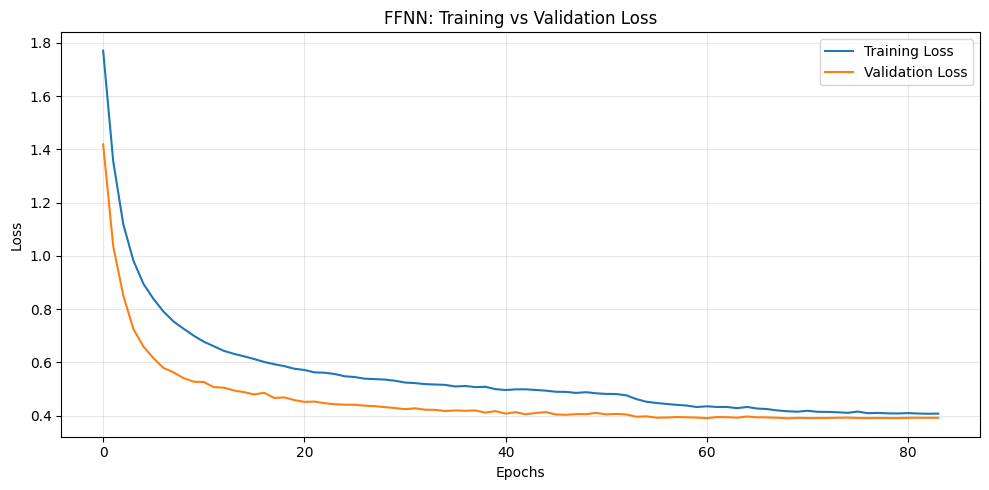

In [15]:
ffnn_model, t_losses, v_losses = train_model(
    model=ffnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=FFNN_HP["num_epochs"],
    patience=FFNN_HP["patience"],
    learning_rate=FFNN_HP["learning_rate"],
    weight_decay=FFNN_HP["weight_decay"],
    scheduler_patience=FFNN_HP["scheduler_patience"],
    scheduler_factor=FFNN_HP["scheduler_factor"],
    class_weights=class_weights_array,
    device=DEVICE,
    save_name="ff_classifier.pkl",
    model_type="ff",
)

plot_losses(t_losses, v_losses, title="FFNN: Training vs Validation Loss")


  FFNN Test Set Evaluation
  Accuracy          : 0.9057
  Balanced Accuracy : 0.8661
  F1 (weighted)     : 0.9056
  F1 (macro)        : 0.8587

              precision    recall  f1-score   support

     Grade A       0.93      0.97      0.95      2654
     Grade B       0.96      0.91      0.94      3774
     Grade C       0.94      0.94      0.94      3708
     Grade D       0.90      0.88      0.89      2126
     Grade E       0.79      0.85      0.82      1208
     Grade F       0.72      0.63      0.67       753
     Grade G       0.73      0.87      0.79       608

    accuracy                           0.91     14831
   macro avg       0.85      0.87      0.86     14831
weighted avg       0.91      0.91      0.91     14831



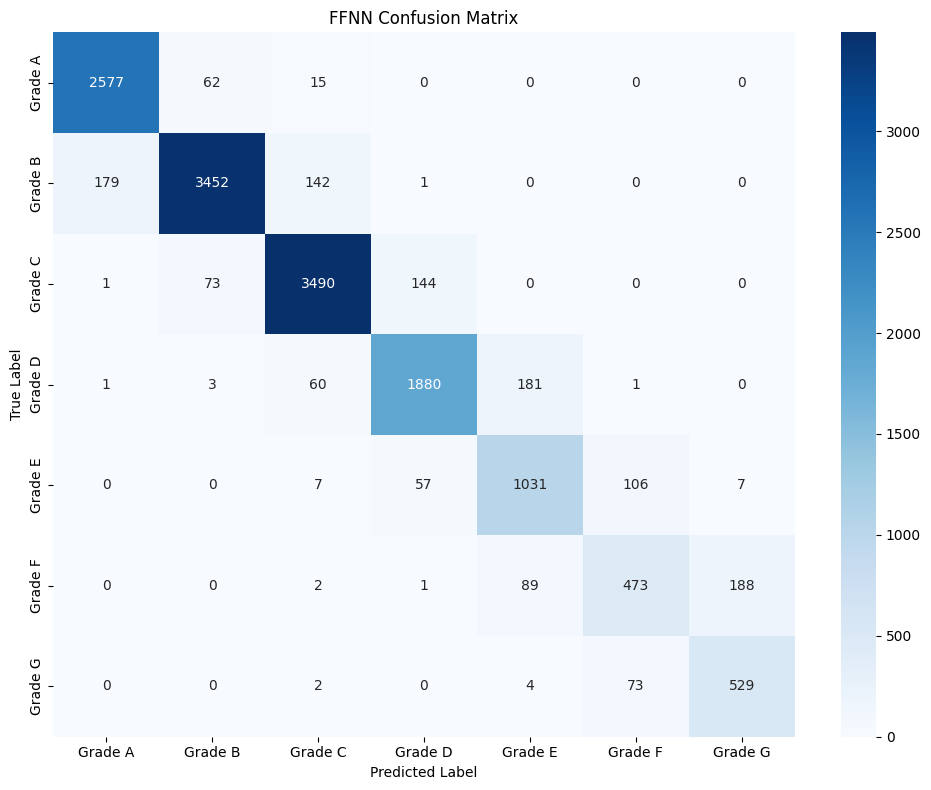

In [16]:
ffnn_results = evaluate_model(
    ffnn_model, test_loader, DEVICE,
    class_names=class_names, model_type="ff", set_name="FFNN Test"
)
plot_confusion_matrix(ffnn_results["y_true"], ffnn_results["y_pred"],
                      class_names=class_names, title="FFNN Confusion Matrix")

### 3.3 Tab Transformer

In [ ]:
# ── TabTransformer Hyperparameters (edit here) ──
TABT_HP = dict(
    # Architecture
    dim=8,
    depth=2,
    heads=4,
    attn_dropout=0.5,
    ff_dropout=0.5,
    mlp_hidden_mults=(2, 1),
    # Training
    num_epochs=100,
    batch_size=2048,
    learning_rate=3e-4,
    weight_decay=0.05,
    patience=10,
    max_grad_norm=1.0,
    use_cosine_scheduler=True,
    warmup_epochs=10,
)

In [ ]:
# Build datasets (TabularDataset splits num/cat)
n_num = dl_data_raw["num_num_cols"]

train_ds_tt = TabularDataset(X_train_np, dl_data_raw["y_train"], meta["num_num_cols"])
val_ds_tt   = TabularDataset(X_val_np,   dl_data_raw["y_val"],   meta["num_num_cols"])
test_ds_tt  = TabularDataset(X_test_np,  dl_data_raw["y_test"],  meta["num_num_cols"])

train_loader_tt, val_loader_tt, test_loader_tt = create_loaders(
    train_ds_tt, val_ds_tt, test_ds_tt, batch_size=TABT_HP["batch_size"]
)

print(f"Numeric: {train_ds_tt.n_num}, Categorical: {train_ds_tt.n_cat}")

In [ ]:
# Build & train TabTransformer
fix_random(SEED)

tab_transformer = build_tab_transformer(
    cat_cardinalities=tuple(meta["cat_cardinalities"]),
    num_continuous=meta["num_num_cols"],
    cont_mean_std=meta["cont_mean_std"],
    num_classes=dl_data_raw["num_classes"],
    dim=TABT_HP["dim"],
    depth=TABT_HP["depth"],
    heads=TABT_HP["heads"],
    attn_dropout=TABT_HP["attn_dropout"],
    ff_dropout=TABT_HP["ff_dropout"],
    mlp_hidden_mults=TABT_HP["mlp_hidden_mults"],
    device=DEVICE,
)

print(tab_transformer)
print(f"Parameters: {sum(p.numel() for p in tab_transformer.parameters()):,}")

In [ ]:
tab_transformer, t_losses_tt, v_losses_tt = train_model(
    model=tab_transformer,
    train_loader=train_loader_tt,
    val_loader=val_loader_tt,
    num_epochs=TABT_HP["num_epochs"],
    patience=TABT_HP["patience"],
    learning_rate=TABT_HP["learning_rate"],
    weight_decay=TABT_HP["weight_decay"],
    #scheduler_patience=TABT_HP["scheduler_patience"],
    #scheduler_factor=TABT_HP["scheduler_factor"],
    class_weights=class_weights_array,
    device=DEVICE,
    save_name="tf.pkl",
    model_type="tab_transformer",
    max_grad_norm=TABT_HP.get("max_grad_norm"),
    use_cosine_scheduler=TABT_HP.get("use_cosine_scheduler", False),
    warmup_epochs=TABT_HP.get("warmup_epochs", 0)
)

plot_losses(t_losses_tt, v_losses_tt, title="TabTransformer: Training vs Validation Loss")

In [ ]:
# Evaluate TabTransformer
tt_results = evaluate_model(
    tab_transformer, test_loader_tt, DEVICE,
    class_names=class_names, model_type="tab_transformer", set_name="TabTransformer Test"
)
plot_confusion_matrix(tt_results["y_true"], tt_results["y_pred"],
                      class_names=class_names, title="TabTransformer Confusion Matrix")

In [ ]:
# 1. Import the wrapper FROM the file (so pickle knows where it lives)
from data_processing import TabTransformerInferenceWrapper
import pickle

# 2. Load your best trained weights
# (Assuming train_model saved "best_tab_transformer.pkl")
with open("models/best_tab_transformer.pkl", "rb") as f:
    best_tt_model = pickle.load(f)

# 3. Get the number of numeric columns
# (You have this in dl_data or meta)
n_num = meta["num_num_cols"] 

# 4. Wrap the model
inference_model = TabTransformerInferenceWrapper(best_tt_model, n_num)
inference_model.eval()
inference_model.cpu() # Essential for portability

# 5. Save the WRAPPER as the final classifier
with open("models/tabtransformer_classifier.pkl", "wb") as f:
    pickle.dump(inference_model, f)

print("Saved Wrapper Model to models/tabtransformer_classifier.pkl")

# 4. Overall Comparison

In [ ]:
print(f"\n{'='*60}")
print(f"  RESULTS COMPARISON")
print(f"{'='*60}")
print(f"{'Model':<20} {'Accuracy':>10} {'Bal Acc':>10} {'F1 macro':>10}")
print(f"{'-'*60}")

# ML models
for name, gs in [("Random Forest", gs_rf), ("KNN", gs_knn), ("SVM", gs_svm)]:
    idx = gs.best_index_
    acc = gs.cv_results_["mean_test_accuracy"][idx]
    bal = gs.cv_results_["mean_test_balanced_accuracy"][idx]
    f1m = gs.cv_results_["mean_test_f1_macro"][idx]
    print(f"{name:<20} {acc:>10.4f} {bal:>10.4f} {f1m:>10.4f}  (CV)")

# DL models 
print(f"{'FFNN':<20} {ffnn_results['accuracy']:>10.4f} {ffnn_results['balanced_accuracy']:>10.4f} {ffnn_results['f1_macro']:>10.4f}  (test)")

tabnet_acc = accuracy_score(y_test, y_pred_tabnet)
tabnet_bal = balanced_accuracy_score(y_test, y_pred_tabnet)
tabnet_f1m = f1_score(y_test, y_pred_tabnet, average="macro")
print(f"{'TabNet':<20} {tabnet_acc:>10.4f} {tabnet_bal:>10.4f} {tabnet_f1m:>10.4f}  (test)")

print(f"{'TabTransformer':<20} {tt_results['accuracy']:>10.4f} {tt_results['balanced_accuracy']:>10.4f} {tt_results['f1_macro']:>10.4f}  (test)")